In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/custom.css
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/outputs/results/xgb_metrics.csv
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/outputs/results/Xgb56_confusion_matrix.png
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/outputs/results/xgb_classification_report.csv
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/outputs/models/lgb_56.pkl
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/__results___files/__results___18_0.png
/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/__results___files/__results___13_0.png
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/__output__.j

In [2]:
rf56 = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/4-random-forest/outputs/results/rf_metrics.csv")
xgb56 = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/4-xgboost/outputs/results/xgb_metrics.csv")
lgb56= pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/feature-seletion-c/outputs/results/lgb_metrics.csv")
cat56= pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/4-catboost/outputs/results/cat_metrics.csv")


In [3]:
rf56["Model"] = "Random Forest"
xgb56["Model"] = "XGBoost"
lgb56["Model"] = "LightGBM"
cat56["Model"] = "CatBoost"


results = pd.concat(
    [rf56, xgb56, lgb56, cat56],
    ignore_index=True
)

cols = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "MCC"
    ]

results = results[cols]

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Random Forest,0.968819,0.966403,0.968819,0.967596,0.981896,0.914026
1,XGBoost,0.981934,0.975410,0.981934,0.974316,0.992104,0.950064
2,LightGBM,0.908929,0.922506,0.908929,0.915017,0.897633,0.752517
3,CatBoost,0.981585,0.975800,0.981585,0.973441,0.989466,0.949108


In [5]:
ranking = results.sort_values(
    by=["F1","Accuracy","AUC"],
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

ranking

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
1,XGBoost,0.981934,0.975410,0.981934,0.974316,0.992104,0.950064
2,CatBoost,0.981585,0.975800,0.981585,0.973441,0.989466,0.949108
3,Random Forest,0.968819,0.966403,0.968819,0.967596,0.981896,0.914026
4,LightGBM,0.908929,0.922506,0.908929,0.915017,0.897633,0.752517


In [6]:
results.style \
    .highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1", "AUC","MCC"],
        color="lightgreen"
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Random Forest,0.9688,0.9664,0.9688,0.9676,0.9819,0.9140
1,XGBoost,0.9819,0.9754,0.9819,0.9743,0.9921,0.9501
2,LightGBM,0.9089,0.9225,0.9089,0.9150,0.8976,0.7525
3,CatBoost,0.9816,0.9758,0.9816,0.9734,0.9895,0.9491


In [12]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

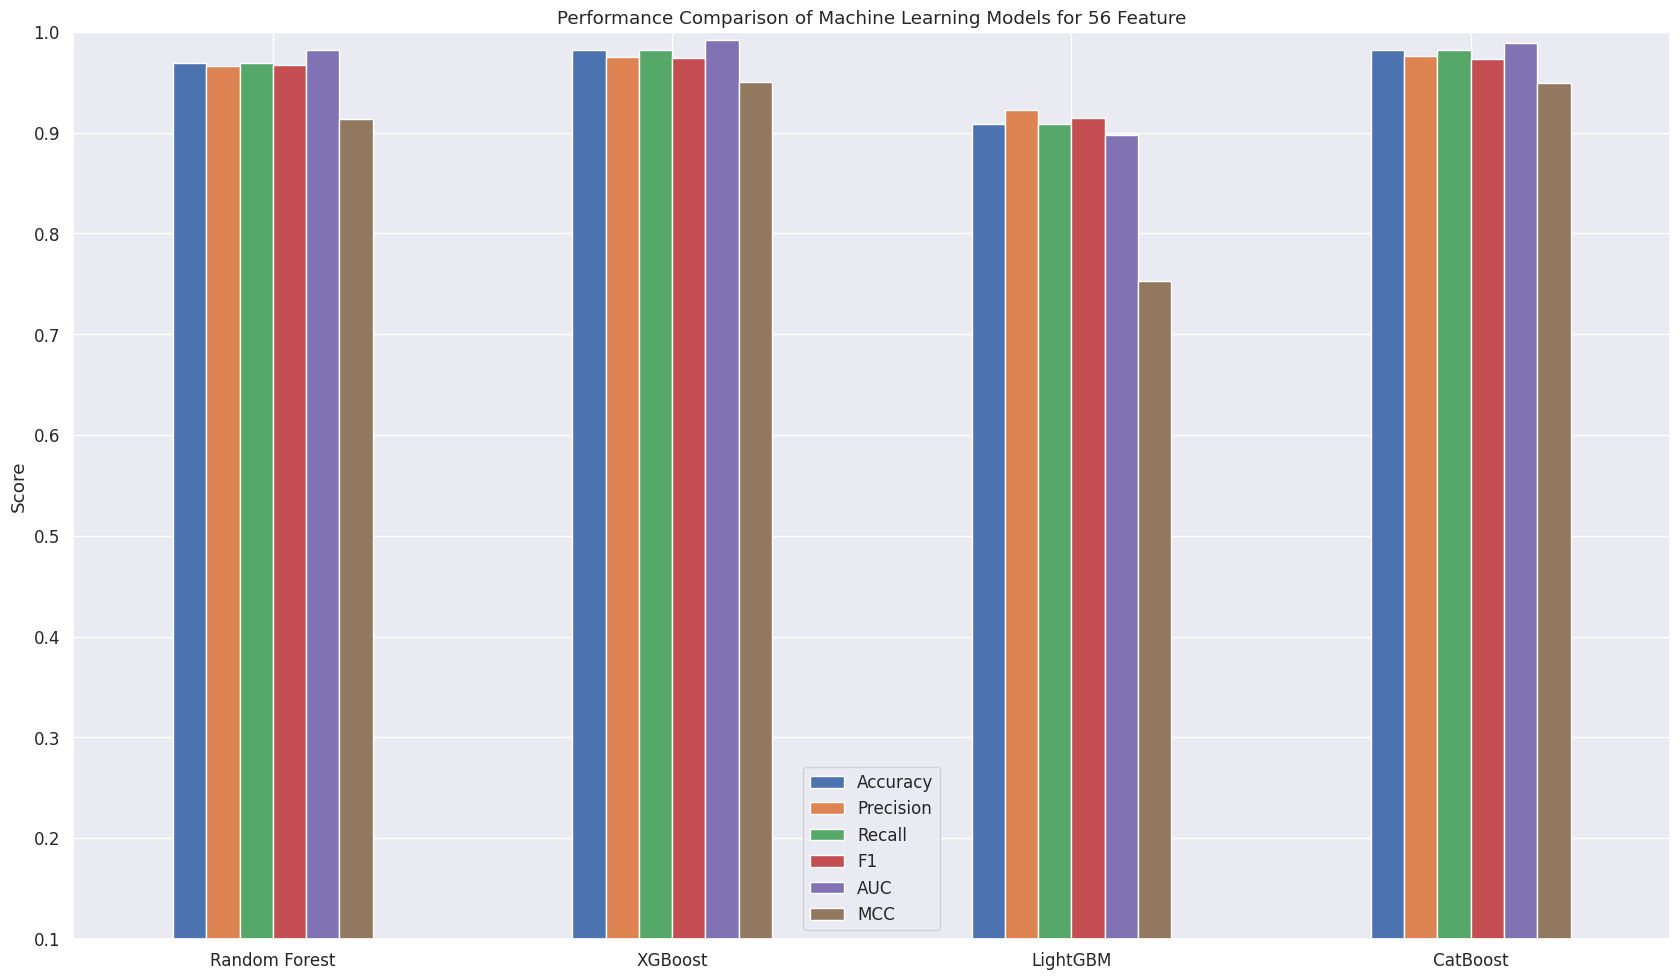

In [14]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "MCC"
]

ax = results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(17,10),
    rot=0
)
plt.ylabel("Score")
plt.xlabel("")
plt.title("Performance Comparison of Machine Learning Models for 56 Feature")
plt.ylim(0.1,1)
plt.grid(True)

plt.tight_layout()



plt.show()